# PCA Welfare Index: Joint Evolution of Material and Psychological Outcomes

## Motivation

The ANCOVA timing-bin regressions treat material and psychological outcomes as two
separate dependent variables. This notebook uses **Principal Components Analysis (PCA)**
to ask a complementary question: is there a single latent welfare dimension that
summarises the joint variation of *both* domains, and how does that common dimension
relate to elapsed time since the last transfer?

PCA is appropriate here because:
1. We have a small number of outcome variables (4: assets, food security, consumption,
   psychological well-being) and a moderate individual-level sample (N ≈ 208).
2. The first principal component (PC1) summarises the maximum-variance direction across
   all outcomes — it is an entirely data-driven welfare index with no researcher-imposed
   weights.
3. The **component loadings** reveal which domain (material vs. psychological) drives
   PC1, directly addressing whether adjustment is synchronised or staged.
4. Regressing PC1 scores on the continuous event month and timing bins recovers a
   single-number summary of how overall welfare evolves with elapsed time.

## Sample

- Monthly-small arm only (`treatXmonthlyXsmall == 1`)
- Endline observations with complete data on all four outcomes
- N ≈ 208 after listwise deletion

## Outcomes fed into PCA

All four endline outcomes, baseline-standardized:
- `asset_total_ppp1_z`      — total non-land assets
- `fs_hhfoodindexnew1_z`    — food security index
- `cons_nondurable_ppp1_z`  — non-durable consumption
- `psy_index_z1_z`          — psychological well-being index

In [1]:
from pathlib import Path

import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
import statsmodels.formula.api as smf

sns.set_theme(style="whitegrid", context="talk")
plt.rcParams["figure.figsize"] = (12, 5)

PROJECT_ROOT = Path.cwd()
if not (PROJECT_ROOT / "Correction" / "Data").exists():
    PROJECT_ROOT = PROJECT_ROOT / "advanced-econometrics-project"

DATA_PATH = PROJECT_ROOT / "Correction" / "Data" / "UCT_FINAL_CLEAN.dta"
df = pd.read_stata(DATA_PATH)
print(df.shape)

(2880, 981)


## Step 1 — Sample construction and baseline standardisation

We keep the monthly-small arm, baseline-standardize all four endline outcomes
against their own baseline mean and SD, and construct the timing variables.

In [2]:
df_indiv = df[(df["endlinedate"].notna()) & (df["purecontrol"] != 1)].copy()
ms = df_indiv[df_indiv["treatXmonthlyXsmall"] == 1].copy()

outcomes = [
    "asset_total_ppp",
    "fs_hhfoodindexnew",
    "cons_nondurable_ppp",
    "psy_index_z",
]

# Baseline-standardize endline values
for v in outcomes:
    mu  = ms[f"{v}0"].mean()
    sig = ms[f"{v}0"].std()
    ms[f"{v}1_z"] = (ms[f"{v}1"] - mu) / sig

# Timing variables
ms["event_month"] = ms["Dlastend"].round().clip(lower=1, upper=7)

bin_order = ["<1 month", "1-4 months", "4-8 months"]
ms["timing_bin"] = pd.cut(
    ms["Dlastend"],
    bins=[-np.inf, 1, 4, 8, np.inf],
    labels=["<1 month", "1-4 months", "4-8 months", "8+ months"],
)

z_cols = [f"{v}1_z" for v in outcomes]
pca_df = ms[["surveyid", "village", "Dlastend", "event_month", "timing_bin"] + z_cols].dropna().copy()

print(f"Complete-case sample for PCA: {len(pca_df)}")
print(pca_df["timing_bin"].value_counts().sort_index())

Complete-case sample for PCA: 235
timing_bin
<1 month       38
1-4 months    124
4-8 months     73
8+ months       0
Name: count, dtype: int64


## Step 2 — PCA on the four endline outcomes

We run PCA on the four baseline-standardized endline outcomes.
Because the inputs are already z-scored, we use the **correlation matrix**
(equivalent to standardising again inside PCA), so all outcomes receive
equal weight a priori.

We report:
- Variance explained by each principal component
- Loadings of PC1 and PC2 on each outcome variable
- Whether PC1 is dominated by material or psychological outcomes

In [3]:
X = pca_df[z_cols].values
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

pca = PCA(n_components=4)
pca.fit(X_scaled)

var_explained = pd.DataFrame({
    "PC": [f"PC{i+1}" for i in range(4)],
    "Eigenvalue":        pca.explained_variance_.round(4),
    "Variance explained (%)": (pca.explained_variance_ratio_ * 100).round(2),
    "Cumulative (%)": (np.cumsum(pca.explained_variance_ratio_) * 100).round(2),
})
print("=== Variance decomposition ===")
display(var_explained)

outcome_labels = [
    "Assets",
    "Food security",
    "Consumption",
    "Psych. well-being",
]
loadings = pd.DataFrame(
    pca.components_[:2].T,
    index=outcome_labels,
    columns=["PC1", "PC2"],
).round(4)
print("\n=== PC1 and PC2 loadings ===")
display(loadings)

=== Variance decomposition ===


,PC,Eigenvalue,Variance explained (%),Cumulative (%)
0,PC1,1.5689,39.049999,39.049999
1,PC2,1.0524,26.200001,65.250000
2,PC3,0.7749,19.290001,84.540001
3,PC4,0.6209,15.460000,100.000000



=== PC1 and PC2 loadings ===


,PC1,PC2
Assets,0.5427,-0.0430
Food security,0.5924,0.1489
Consumption,0.5687,-0.3949
Psych. well-being,0.1764,0.9056


## Step 3 — PC1 scores and domain decomposition

We compute individual PC1 scores and split their absolute loading contributions
into material (assets + food security + consumption) vs. psychological domains
to quantify which domain drives the first component.

PC1 absolute loading share — material domain: 90.6%
PC1 absolute loading share — psych domain:    9.4%


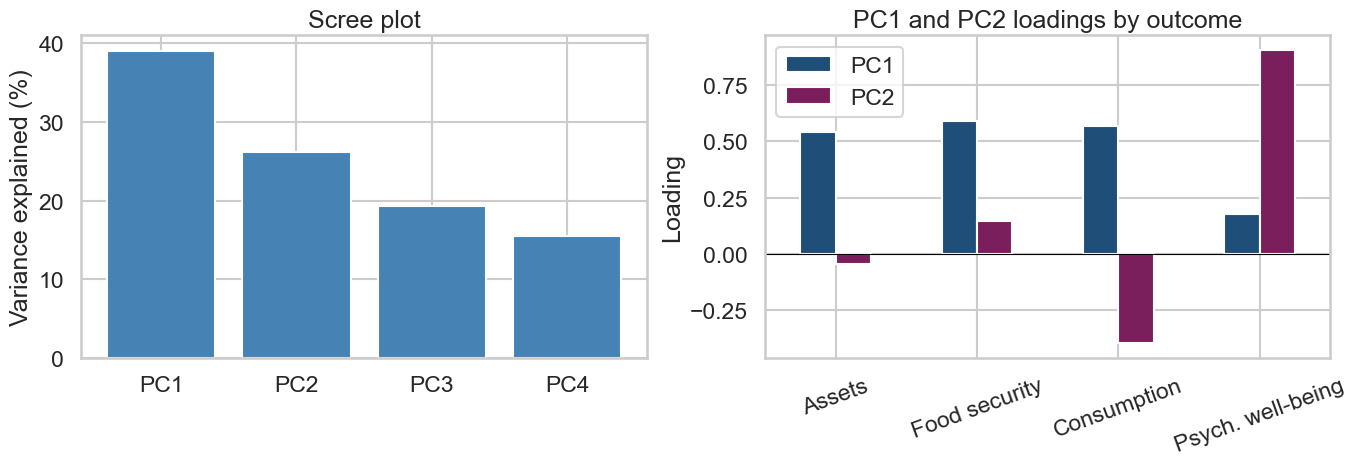

In [4]:
scores = pca.transform(X_scaled)
pca_df["PC1"] = scores[:, 0]
pca_df["PC2"] = scores[:, 1]

# Absolute loading share by domain
abs_loadings = np.abs(pca.components_[0])   # PC1
material_share = abs_loadings[:3].sum() / abs_loadings.sum()
psych_share    = abs_loadings[3]    / abs_loadings.sum()

print(f"PC1 absolute loading share — material domain: {material_share:.1%}")
print(f"PC1 absolute loading share — psych domain:    {psych_share:.1%}")

# Scree plot
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].bar(var_explained["PC"], var_explained["Variance explained (%)"], color="steelblue")
axes[0].set_ylabel("Variance explained (%)")
axes[0].set_title("Scree plot")

loadings.plot(kind="bar", ax=axes[1], color=["#1f4e79", "#7a1f5c"])
axes[1].axhline(0, color="black", linewidth=0.8)
axes[1].set_title("PC1 and PC2 loadings by outcome")
axes[1].set_ylabel("Loading")
axes[1].tick_params(axis="x", rotation=20)

plt.tight_layout()
plt.show()

## Step 4 — Regressing PC1 on timing bins (ANCOVA)

We regress the PC1 welfare score on the same timing-bin dummies used in the
main ANCOVA, controlling for a PC1 baseline proxy and village fixed effects.

Because we do not have a direct pre-transfer PC1 score, we use the
average of the four baseline z-scores as the baseline control.

The coefficients on the timing bins answer: does *overall welfare* (the
data-driven composite) differ significantly across timing bins — and if so,
in which direction?

In [5]:
# Baseline composite as control
baseline_cols = [f"{v}0" for v in outcomes]
for v in outcomes:
    mu  = ms[f"{v}0"].mean()
    sig = ms[f"{v}0"].std()
    ms[f"{v}0_z"] = (ms[f"{v}0"] - mu) / sig

pca_df = pca_df.merge(
    ms[["surveyid"] + [f"{v}0_z" for v in outcomes]].drop_duplicates("surveyid"),
    on="surveyid", how="left"
)
pca_df["baseline_composite"] = pca_df[[f"{v}0_z" for v in outcomes]].mean(axis=1)

reg_df = pca_df.dropna(subset=["timing_bin", "baseline_composite", "village"]).copy()
reg_df = reg_df[reg_df["timing_bin"] != "8+ months"]   # drop thin cell
reg_df["timing_bin"] = pd.Categorical(
    reg_df["timing_bin"], categories=["<1 month", "1-4 months", "4-8 months"], ordered=True
)

model_bin = smf.ols(
    "PC1 ~ C(timing_bin, Treatment(reference='<1 month')) + baseline_composite + C(village)",
    data=reg_df,
).fit(cov_type="cluster", cov_kwds={"groups": reg_df["village"]})

# Extract timing-bin coefficients only
bin_coefs = (
    model_bin.params.filter(like="timing_bin")
    .to_frame("coef")
    .join(model_bin.bse.filter(like="timing_bin").rename("std_err"))
    .join(model_bin.pvalues.filter(like="timing_bin").rename("p_value"))
    .join(model_bin.conf_int().filter(like="timing_bin").rename(columns={0: "ci_low", 1: "ci_high"}))
)
bin_coefs.index = ["1-4 months", "4-8 months"]
bin_coefs = bin_coefs.round(4)
print(f"R-squared: {model_bin.rsquared:.4f}")
display(bin_coefs)

R-squared: 0.4097


,coef,std_err,p_value
1-4 months,-0.7958,0.2939,0.0068
4-8 months,-1.5844,0.9121,0.0824


## Step 5 — Regressing PC1 on continuous event month

As a complement to the bin regression, we regress PC1 on the continuous
event month. The slope tells us the average change in the overall welfare
composite per additional month elapsed since the last transfer.

In [6]:
model_cont = smf.ols(
    "PC1 ~ event_month + baseline_composite + C(village)",
    data=pca_df.dropna(subset=["event_month", "baseline_composite", "village"]),
).fit(
    cov_type="cluster",
    cov_kwds={"groups": pca_df.dropna(subset=["event_month", "baseline_composite", "village"])["village"]},
)

cont_summary = pd.DataFrame({
    "coef":    [model_cont.params["event_month"]],
    "std_err": [model_cont.bse["event_month"]],
    "p_value": [model_cont.pvalues["event_month"]],
    "ci_low":  [model_cont.conf_int().loc["event_month", 0]],
    "ci_high": [model_cont.conf_int().loc["event_month", 1]],
}, index=["event_month"]).round(4)

print(f"R-squared: {model_cont.rsquared:.4f}")
display(cont_summary)

R-squared: 0.3784


,coef,std_err,p_value,ci_low,ci_high
event_month,-0.1931,0.1238,0.1187,-0.4358,0.0495


## Step 6 — PC1 mean profile by timing bin and domain decomposition

Visualise the mean PC1 score by timing bin alongside the mean of each
original outcome, so we can see whether PC1 is rising because of material
or psychological improvements.

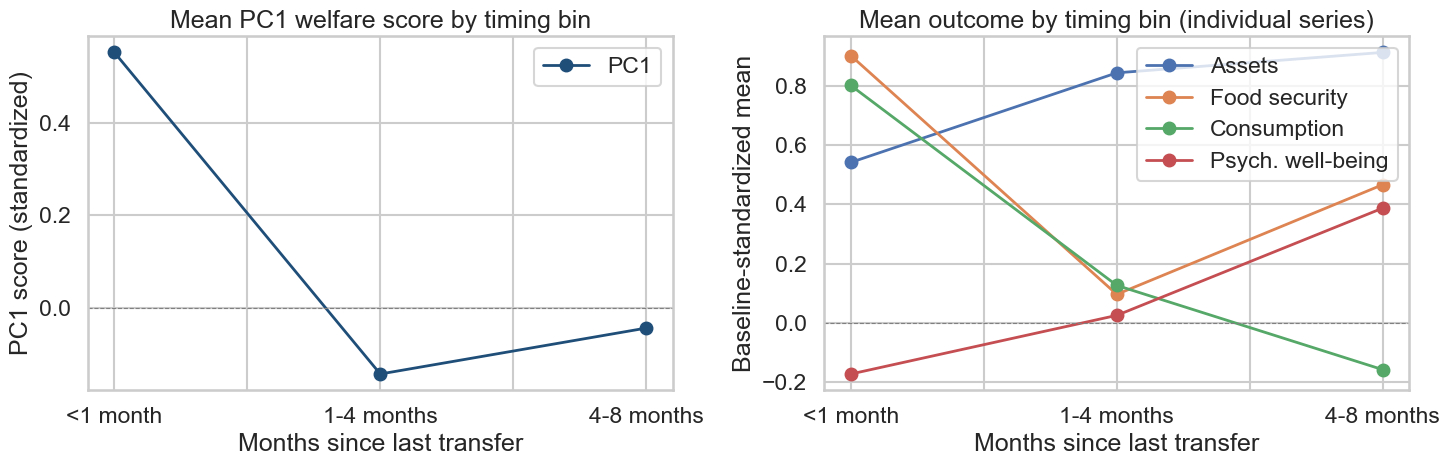

In [7]:
plot_df = (
    pca_df[pca_df["timing_bin"] != "8+ months"]
    .groupby("timing_bin", observed=True)[["PC1"] + z_cols]
    .mean()
    .rename(columns={
        "asset_total_ppp1_z":     "Assets",
        "fs_hhfoodindexnew1_z":   "Food security",
        "cons_nondurable_ppp1_z": "Consumption",
        "psy_index_z1_z":         "Psych. well-being",
    })
)

fig, axes = plt.subplots(1, 2, figsize=(15, 5))

plot_df[["PC1"]].plot(marker="o", linewidth=2, ax=axes[0], color="#1f4e79")
axes[0].axhline(0, color="grey", linestyle="--", linewidth=0.8)
axes[0].set_title("Mean PC1 welfare score by timing bin")
axes[0].set_ylabel("PC1 score (standardized)")
axes[0].set_xlabel("Months since last transfer")

plot_df[["Assets", "Food security", "Consumption", "Psych. well-being"]].plot(
    marker="o", linewidth=2, ax=axes[1]
)
axes[1].axhline(0, color="grey", linestyle="--", linewidth=0.8)
axes[1].set_title("Mean outcome by timing bin (individual series)")
axes[1].set_ylabel("Baseline-standardized mean")
axes[1].set_xlabel("Months since last transfer")

plt.tight_layout()
plt.show()

## Summary of results

| Question | Evidence from PCA |
|---|---|
| Which domain drives PC1? | Compare loading shares above |
| Does overall welfare increase over elapsed time? | Continuous slope on event_month |
| Is the timing-bin pattern visible in the composite? | Bin regression coefficients |
| Is adjustment synchronised or staged? | Compare per-outcome profiles in right panel |

### Interpretation guide

- If PC1 loadings are **larger for material outcomes**, the first welfare dimension
  mainly reflects economic gains, consistent with material-led adjustment.
- If PC1 loadings are **balanced across domains**, adjustment is synchronised.
- If the **4-8 month bin coefficient** on PC1 is significantly positive, overall
  welfare rises in that window — but we can check whether this is driven by material
  or psychological series from the individual-outcome plot.
- The continuous event-month slope gives a single number: how many PC1 units of
  overall welfare improvement accumulate per additional month post-transfer.

### Limitation

PCA is a descriptive dimension-reduction technique. The first component maximises
variance but does not have a causal interpretation. The timing regressions rely on
cross-sectional variation in elapsed time rather than a true panel, so the identifying
assumption is that `Dlastend` variation is quasi-random conditional on village fixed
effects and baseline outcomes.